# D3-02 Inspecting and comparing premise outputs in Brightway

Audience:
- Participants who already generated the Paris course `premise` databases in `D3-01`.

Prerequisites:
- `paris-lca-course-2026` is active.
- The REMIND-EU scenario databases were written successfully in Brightway.

Learning goals:
- Gather comparable electricity market activities across the generated scenario databases.
- Extract `scenario` and `year` from the database names into a tidy pandas table.
- Compare regional electricity markets over time across the full `("ecoinvent-3.12", "EF v3.1", ...)` method family.


## Outline

1. Collect matching electricity market activities from the generated scenario databases.
2. Build a tidy DataFrame with activity metadata plus `scenario` and `year`.
3. Plot a three-column grid of relative score trajectories, one subplot per EF indicator.


In [7]:
import math
import textwrap

import bw2calc as bc
import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

project_name = "paris-lca-course-2026"
db_keyword = "_remind-eu_"
target_activity = "market group for electricity, high voltage"
target_locations = ["FRA", "DEU", "UKI", ]
scenario_order = ["SSP2-NPi", "SSP2-PkBudg1000"]
method_family_prefix = ("ecoinvent-3.12", "EF v3.1")

bd.projects.set_current(project_name)
scenario_dbs = sorted(db for db in bd.databases if db_keyword in db)
indicator_methods = sorted(
    [
        method
        for method in bd.methods
        if isinstance(method, tuple) and len(method) >= 3 and method[:2] == method_family_prefix
    ],
    key=lambda method: method[2:],
)


## Step 1 - Build a tidy electricity market table

We collect the same high-voltage electricity market across the generated scenario databases for the
regional markets `FRA`, `DEU`, `ESC`, `ESW`, `ENC`, `UKI`, and `ECE`, then extract `scenario` and
`year` directly from each database name.


In [8]:
activity_rows = []
activity_lookup = {}

for db_name in scenario_dbs:
    for activity in bd.Database(db_name):
        if activity["name"] == target_activity and activity["location"] in target_locations:
            activity_lookup[(db_name, activity["location"])] = activity
            activity_rows.append(
                {
                    "database_name": db_name,
                    "activity_name": activity["name"],
                    "reference_product": activity.get("reference product"),
                    "location": activity.get("location"),
                }
            )

electricity_markets = pd.DataFrame(activity_rows)
if electricity_markets.empty:
    raise ValueError(
        f"No '{target_activity}' activities found for locations {target_locations}."
    )

electricity_markets[["scenario", "year"]] = electricity_markets["database_name"].str.extract(
    r"_remind-eu_(.+)_(\d{4})(?:\s|$)"
)
if electricity_markets[["scenario", "year"]].isna().any().any():
    raise ValueError("Could not extract scenario and year from one or more database names.")

electricity_markets["year"] = electricity_markets["year"].astype(int)
electricity_markets["location"] = pd.Categorical(
    electricity_markets["location"],
    categories=target_locations,
    ordered=True,
)
electricity_markets["scenario"] = pd.Categorical(
    electricity_markets["scenario"],
    categories=scenario_order,
    ordered=True,
)
electricity_markets = electricity_markets.sort_values(["scenario", "year", "location"]).reset_index(drop=True)

expected_pairs = {(db_name, location) for db_name in scenario_dbs for location in target_locations}
found_pairs = {
    (row["database_name"], str(row["location"]))
    for _, row in electricity_markets[["database_name", "location"]].iterrows()
}
missing_pairs = sorted(expected_pairs - found_pairs)
if missing_pairs:
    missing_preview = ", ".join(f"{db_name} / {location}" for db_name, location in missing_pairs[:6])
    raise ValueError(f"Missing electricity markets for some database-location pairs: {missing_preview}")

print(f"Found {len(scenario_dbs)} REMIND-EU databases and {len(indicator_methods)} matching EF v3.1 indicators.")

electricity_markets[
    ["activity_name", "reference_product", "location", "scenario", "year"]
].rename(
    columns={
        "activity_name": "activity name",
        "reference_product": "reference product",
    }
)


Found 5 REMIND-EU databases and 25 matching EF v3.1 indicators.


,activity name,reference product,location,scenario,year
0,"market group for electricity, high voltage","electricity, high voltage",FRA,SSP2-NPi,2025
1,"market group for electricity, high voltage","electricity, high voltage",DEU,SSP2-NPi,2025
2,"market group for electricity, high voltage","electricity, high voltage",UKI,SSP2-NPi,2025
3,"market group for electricity, high voltage","electricity, high voltage",FRA,SSP2-NPi,2035
4,"market group for electricity, high voltage","electricity, high voltage",DEU,SSP2-NPi,2035
5,"market group for electricity, high voltage","electricity, high voltage",UKI,SSP2-NPi,2035
6,"market group for electricity, high voltage","electricity, high voltage",FRA,SSP2-NPi,2050
7,"market group for electricity, high voltage","electricity, high voltage",DEU,SSP2-NPi,2050
8,"market group for electricity, high voltage","electricity, high voltage",UKI,SSP2-NPi,2050
9,"market group for electricity, high voltage","electricity, high voltage",FRA,SSP2-PkBudg1000,2035


## Step 2 - Plot relative regional trajectories for all EF indicators

We calculate every indicator in the method family `("ecoinvent-3.12", "EF v3.1", ...)` for the selected
regional electricity markets. We still reuse each characterization matrix only once, but we do this
within one scenario database at a time. That matters because `redo_lci` is only safe when the products
share the same technosphere. Each subplot shows one indicator, with scores indexed to `2025 = 100` for
each region. Because `D3-01` does not generate `SSP2-PkBudg1000` for 2025, we use `SSP2-NPi 2025` as
its explicit proxy baseline and starting point.


In [9]:
def get_lcia_scores(products, categories):
    results = np.zeros((len(products), len(categories)))

    lca = bc.LCA({products[0].id: 1}, categories[0])
    lca.lci()
    lca.lcia()

    # Build each characterization matrix once, then reuse it across compatible products.
    method_matrices = [lca.characterization_matrix.copy()]
    for other_method in categories[1:]:
        lca.switch_method(other_method)
        method_matrices.append(lca.characterization_matrix.copy())

    for product_index, product in enumerate(products):
        lca.redo_lci({product.id: 1})
        for method_index, characterization_matrix in enumerate(method_matrices):
            results[product_index, method_index] = (characterization_matrix * lca.inventory).sum()

    return results


In [10]:
indicator_order = [" | ".join(method[2:]) for method in indicator_methods]
score_frames = []

for database_name, db_rows in electricity_markets.groupby("database_name", sort=False, observed=True):
    group = db_rows.reset_index(drop=True).copy()
    products = [
        activity_lookup[(row["database_name"], str(row["location"]))]
        for _, row in group.iterrows()
    ]
    score_matrix = get_lcia_scores(products, indicator_methods)

    score_frames.append(
        group.assign(row_id=np.arange(len(group)))
        [["database_name", "scenario", "year", "location", "row_id"]]
        .merge(
            pd.DataFrame(score_matrix, columns=indicator_order)
            .assign(row_id=np.arange(len(group)))
            .melt(id_vars="row_id", var_name="indicator", value_name="score"),
            on="row_id",
            how="left",
        )
        .drop(columns="row_id")
    )

absolute_scores = pd.concat(score_frames, ignore_index=True)
absolute_scores["scenario"] = absolute_scores["scenario"].astype(str)
absolute_scores["location"] = absolute_scores["location"].astype(str)
absolute_scores["is_proxy"] = False

print(f"Computed {len(electricity_markets)} electricity markets across {len(indicator_methods)} indicators.")


/opt/homebrew/Caskroom/miniforge/base/envs/lca-course/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:736: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 8.15e+12)
  warnings.warn(msg, UmfpackWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/lca-course/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:736: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 7.65e+12)
  warnings.warn(msg, UmfpackWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/lca-course/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:736: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 9.40e+12)
  warnings.warn(msg, UmfpackWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/lca-course/lib/python3.11/site-packages/scikits/umfpack/umfpack.py:736: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 7.65e+12)
  warnings.warn(msg, UmfpackWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/lca-course/lib/python3.11/site-packages/s

Computed 15 electricity markets across 25 indicators.


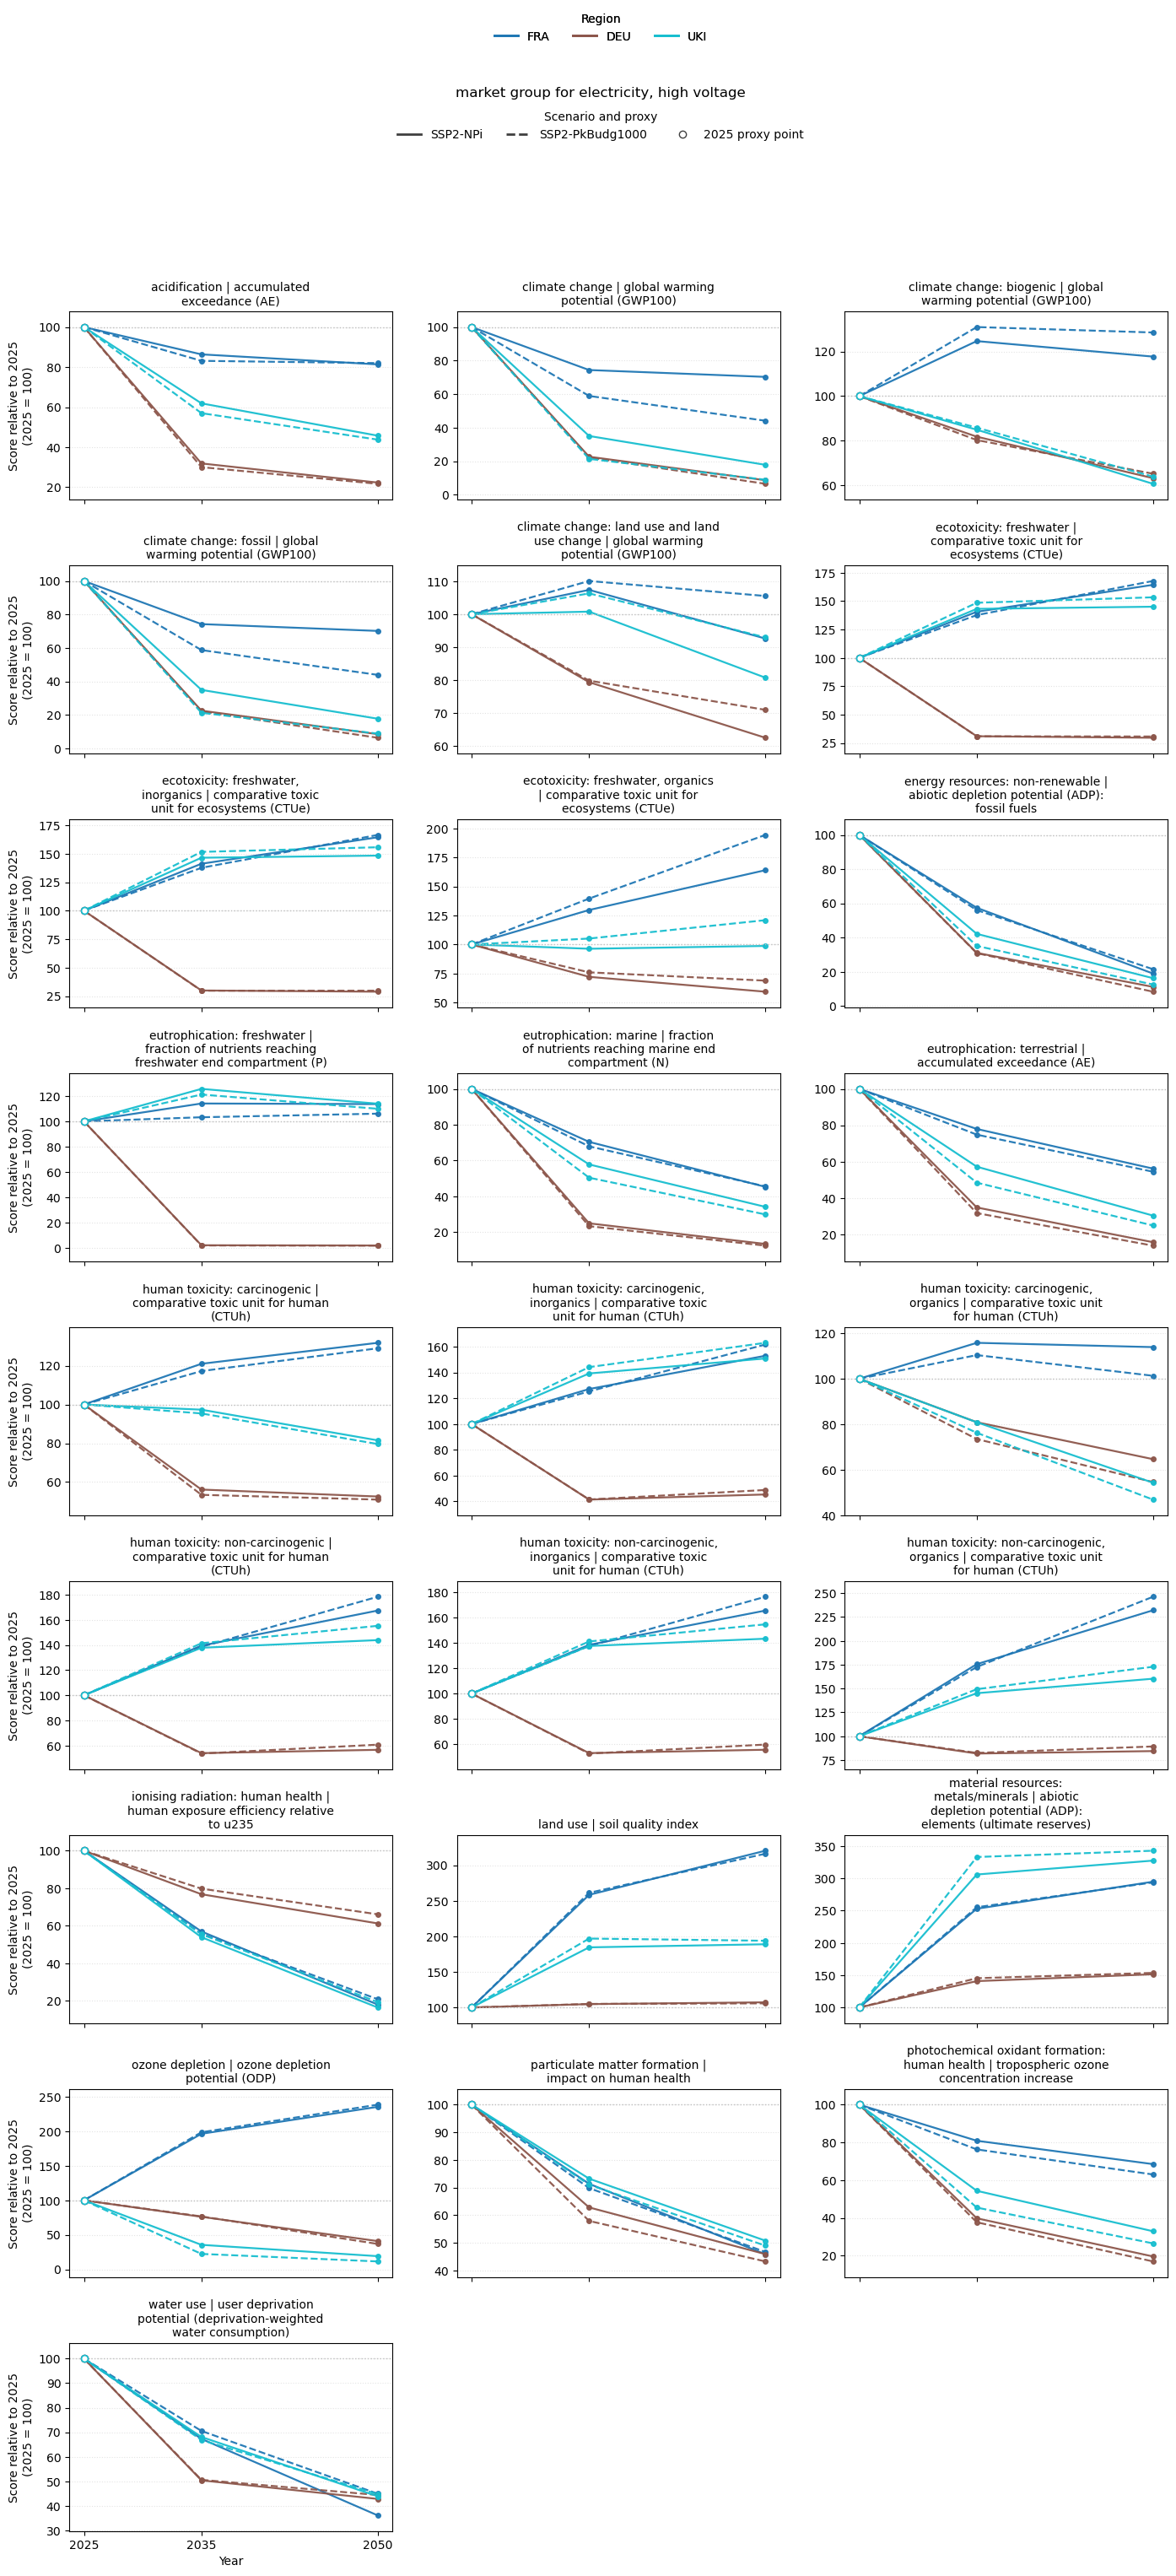

,indicator,scenario,location,year,score,baseline_2025,relative_to_2025,is_proxy
0,acidification | accumulated exceedance (AE),SSP2-NPi,FRA,2025,0.000124,0.000124,100.000000,False
1,acidification | accumulated exceedance (AE),SSP2-NPi,FRA,2035,0.000107,0.000124,86.354053,False
2,acidification | accumulated exceedance (AE),SSP2-NPi,FRA,2050,0.000101,0.000124,81.357867,False
3,acidification | accumulated exceedance (AE),SSP2-NPi,DEU,2025,0.000598,0.000598,100.000000,False
4,acidification | accumulated exceedance (AE),SSP2-NPi,DEU,2035,0.000191,0.000598,31.887844,False
...,...,...,...,...,...,...,...,...
445,water use | user deprivation potential (depriv...,SSP2-PkBudg1000,DEU,2035,0.023088,0.045609,50.621050,False
446,water use | user deprivation potential (depriv...,SSP2-PkBudg1000,DEU,2050,0.020267,0.045609,44.436634,False
447,water use | user deprivation potential (depriv...,SSP2-PkBudg1000,UKI,2025,0.039436,0.039436,100.000000,True
448,water use | user deprivation potential (depriv...,SSP2-PkBudg1000,UKI,2035,0.026358,0.039436,66.838241,False


In [11]:
proxy_rows = absolute_scores.loc[
    (absolute_scores["scenario"] == "SSP2-NPi") & (absolute_scores["year"] == 2025)
].copy()
proxy_rows["scenario"] = "SSP2-PkBudg1000"
proxy_rows["is_proxy"] = True

comparison_scores = pd.concat([absolute_scores, proxy_rows], ignore_index=True)
baseline_2025 = absolute_scores.loc[
    (absolute_scores["scenario"] == "SSP2-NPi") & (absolute_scores["year"] == 2025),
    ["location", "indicator", "score"],
].rename(columns={"score": "baseline_2025"})

comparison_scores = comparison_scores.merge(
    baseline_2025,
    on=["location", "indicator"],
    how="left",
)
if comparison_scores["baseline_2025"].isna().any():
    raise ValueError("Missing a 2025 SSP2-NPi baseline for at least one region-indicator pair.")
if (comparison_scores["baseline_2025"] == 0).any():
    raise ValueError("At least one 2025 SSP2-NPi baseline is zero, so relative scores cannot be computed.")

comparison_scores["relative_to_2025"] = (
    comparison_scores["score"] / comparison_scores["baseline_2025"] * 100
)
comparison_scores["location"] = pd.Categorical(
    comparison_scores["location"],
    categories=target_locations,
    ordered=True,
)
comparison_scores["scenario"] = pd.Categorical(
    comparison_scores["scenario"],
    categories=scenario_order,
    ordered=True,
)
comparison_scores = comparison_scores.sort_values(
    ["indicator", "scenario", "location", "year"]
).reset_index(drop=True)

region_colors = dict(zip(target_locations, plt.cm.tab10(np.linspace(0, 1, len(target_locations)))))
scenario_styles = {"SSP2-NPi": "-", "SSP2-PkBudg1000": "--"}

ncols = 3
nrows = math.ceil(len(indicator_order) / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.6 * ncols, 3.7 * nrows),
    sharex=True,
    squeeze=False,
)
axes = axes.ravel()

years = sorted(comparison_scores["year"].unique())
for ax, indicator in zip(axes, indicator_order):
    indicator_data = comparison_scores.loc[comparison_scores["indicator"] == indicator]

    for location in target_locations:
        for scenario in scenario_order:
            line_data = indicator_data.loc[
                (indicator_data["location"] == location)
                & (indicator_data["scenario"] == scenario)
            ].sort_values("year")
            if line_data.empty:
                continue

            ax.plot(
                line_data["year"],
                line_data["relative_to_2025"],
                color=region_colors[location],
                linestyle=scenario_styles[scenario],
                marker="o",
                linewidth=1.6,
                markersize=4,
                alpha=0.95,
            )

            proxy_points = line_data.loc[line_data["is_proxy"]]
            if not proxy_points.empty:
                ax.scatter(
                    proxy_points["year"],
                    proxy_points["relative_to_2025"],
                    s=32,
                    facecolors="white",
                    edgecolors=region_colors[location],
                    linewidth=1.2,
                    zorder=4,
                )

    ax.axhline(100, color="0.75", linestyle=":", linewidth=1)
    ax.set_title(textwrap.fill(indicator, width=34), fontsize=10)
    ax.set_xticks(years)
    ax.grid(axis="y", linestyle=":", alpha=0.35)
    ax.margins(y=0.1)

for extra_ax in axes[len(indicator_order):]:
    extra_ax.axis("off")

for ax in axes[::ncols]:
    ax.set_ylabel("Score relative to 2025\n(2025 = 100)")
for ax in axes[-ncols:]:
    if ax.has_data():
        ax.set_xlabel("Year")

region_handles = [
    Line2D([0], [0], color=region_colors[location], linewidth=2, label=location)
    for location in target_locations
]
style_handles = [
    Line2D([0], [0], color="0.25", linewidth=2, linestyle=scenario_styles[scenario], label=scenario)
    for scenario in scenario_order
]
proxy_handle = Line2D(
    [0],
    [0],
    color="0.25",
    marker="o",
    markerfacecolor="white",
    markeredgecolor="0.25",
    linewidth=0,
    label="2025 proxy point",
)

region_legend = fig.legend(
    handles=region_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(target_locations),
    frameon=False,
    title="Region",
)
fig.add_artist(region_legend)
fig.legend(
    handles=style_handles + [proxy_handle],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=3,
    frameon=False,
    title="Scenario and proxy",
)
fig.suptitle(target_activity)
fig.subplots_adjust(top=0.9, hspace=0.35, wspace=0.2)
plt.show()

comparison_scores[
    [
        "indicator",
        "scenario",
        "location",
        "year",
        "score",
        "baseline_2025",
        "relative_to_2025",
        "is_proxy",
    ]
]
